#Đọc và kiểm tra dữ liệu ban đầu

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Tải dữ liệu từ file CSV
df = pd.read_csv('https://raw.githubusercontent.com/huynhhoc/DataAnalystDeepLearning/main/Data/dulieuxettuyendaihoc.csv')

# Xem thử 5 dòng đầu tiên và thông tin các cột
print("Dữ liệu ban đầu:")
display(df.head())
print("\nThông tin dữ liệu:")
df.info()

Dữ liệu ban đầu:


,STT,T1,L1,H1,S1,V1,X1,D1,N1,T2,...,X6,D6,N6,GT,DT,KV,DH1,DH2,DH3,KT
0,1,7.2,7.3,6.3,7.3,7.0,7.9,7.3,5.5,8.4,...,6.6,7.6,5.9,F,NaN,2NT,3.25,3.25,4.50,A1
1,2,5.4,3.9,3.9,4.0,5.4,5.4,5.3,2.8,6.3,...,6.6,6.1,4.4,M,NaN,1,6.00,4.00,3.50,C
2,3,5.6,6.8,7.2,7.5,4.3,7.4,5.8,3.2,5.0,...,7.9,8.1,4.6,M,NaN,1,5.00,6.75,4.00,C
3,4,6.6,6.4,5.3,6.9,5.4,7.3,6.4,5.8,5.1,...,7.1,7.3,7.4,M,NaN,1,4.25,4.25,5.25,D1
4,5,6.0,5.0,6.0,7.3,6.5,7.7,7.9,6.1,5.4,...,6.1,7.5,7.2,M,NaN,2NT,4.25,4.50,5.00,A



Thông tin dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 56 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   STT     100 non-null    int64  
 1   T1      100 non-null    float64
 2   L1      100 non-null    float64
 3   H1      100 non-null    float64
 4   S1      100 non-null    float64
 5   V1      100 non-null    float64
 6   X1      100 non-null    float64
 7   D1      100 non-null    float64
 8   N1      100 non-null    float64
 9   T2      100 non-null    float64
 10  L2      100 non-null    float64
 11  H2      100 non-null    float64
 12  S2      100 non-null    float64
 13  V2      100 non-null    float64
 14  X2      100 non-null    float64
 15  D2      100 non-null    float64
 16  N2      100 non-null    float64
 17  T3      100 non-null    float64
 18  L3      100 non-null    float64
 19  H3      100 non-null    float64
 20  S3      100 non-null    float64
 21  V3      100 non-null

#Xử lý dữ liệu bị thiếu (đầy đủ không?)

In [2]:
# Kiểm tra số lượng dữ liệu bị thiếu
print("Số lượng dữ liệu thiếu trước khi xử lý:")
print(df.isnull().sum()[df.isnull().sum() > 0]) # Chỉ in ra các cột bị thiếu

# Xử lý: Điền giá trị 0 vào cột DT bị thiếu
df['DT'] = df['DT'].fillna(0)

print("\nĐã xử lý xong dữ liệu thiếu!")

Số lượng dữ liệu thiếu trước khi xử lý:
DT    97
dtype: int64

Đã xử lý xong dữ liệu thiếu!


#Chuyển chuỗi thành số (String -> Số)

In [3]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

# Chuyển đổi các cột chuỗi thành số
df['GT'] = encoder.fit_transform(df['GT'])
df['KV'] = encoder.fit_transform(df['KV'])
df['KT'] = encoder.fit_transform(df['KT'])

print("Dữ liệu sau khi chuyển chuỗi thành số:")
display(df[['GT', 'KV', 'KT']].head())

Dữ liệu sau khi chuyển chuỗi thành số:


,GT,KV,KT
0,0,2,1
1,1,0,3
2,1,0,3
3,1,0,4
4,1,2,0


#Xử lý ngoại lệ (Outlier - IQR)

In [4]:
# Tạo cột Tổng điểm Đại học để dễ xét Outlier
df['Tong_DH'] = df['DH1'] + df['DH2'] + df['DH3']

# Tính Q1 (25%) và Q3 (75%)
Q1 = df['Tong_DH'].quantile(0.25)
Q3 = df['Tong_DH'].quantile(0.75)

# Tính IQR
IQR = Q3 - Q1

# Xác định giới hạn
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Lọc bỏ Outlier
df_clean = df[(df['Tong_DH'] >= lower_bound) & (df['Tong_DH'] <= upper_bound)]

print(f"Giới hạn bình thường của tổng điểm: từ {lower_bound:.2f} đến {upper_bound:.2f}")
print(f"Số lượng dữ liệu ban đầu: {len(df)}, sau khi xóa Outlier: {len(df_clean)}")

Giới hạn bình thường của tổng điểm: từ 7.75 đến 17.75
Số lượng dữ liệu ban đầu: 100, sau khi xóa Outlier: 96


#Ma trận tương quan (Correlation Matrix - Heatmap)

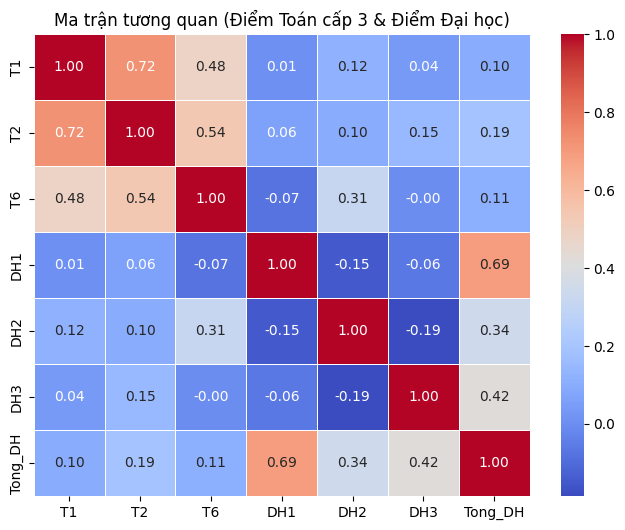

In [5]:
# Chọn một vài cột quan trọng để vẽ ma trận tương quan
cols_to_plot = ['T1', 'T2', 'T6', 'DH1', 'DH2', 'DH3', 'Tong_DH']
corr_matrix = df_clean[cols_to_plot].corr()

# Vẽ Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Ma trận tương quan (Điểm Toán cấp 3 & Điểm Đại học)')
plt.show()

#Phân chia Input và Target

In [6]:
# Target/Output (y) là Tổng điểm thi Đại học
y = df_clean['Tong_DH']

# Input (X) là tất cả các điểm cấp 3 và thông tin khác (bỏ cột STT, và các cột điểm ĐH)
X = df_clean.drop(columns=['STT', 'DH1', 'DH2', 'DH3', 'Tong_DH'])

print("Kích thước của bảng Input (X):", X.shape)
print("Kích thước của cột Target (y):", y.shape)
print("\nHoàn tất quá trình tiền xử lý! Dữ liệu đã sẵn sàng để train model.")

Kích thước của bảng Input (X): (96, 52)
Kích thước của cột Target (y): (96,)

Hoàn tất quá trình tiền xử lý! Dữ liệu đã sẵn sàng để train model.
